# Intermitencia de demanda semanal por sucursal-producto
Este cuaderno usa el mismo constructor `W-SUN` del experimento ML sobre el CSV maestro. Se incluyen todas las combinaciones observadas, sin eliminar series por intermitencia ni por falta de lags.

Se rellenan únicamente semanas interiores sin transacciones, bajo el supuesto de continuidad de captura. Un NaN de origen provoca un error y no se convierte en cero. Las combinaciones nunca observadas no se inventan. Los extremos de cada serie pueden ser semanas parciales; cajas cero puede coexistir con ventas en unidades.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, str(Path('..').resolve()))
from src.preprocessing.demanda_semanal import construir_semanal, resumir_intermitencia

df = pd.read_csv('../datasets/dataset_maestro_dashboard.csv')
semanal = construir_semanal(df)
df_intermitencia = resumir_intermitencia(semanal)
salida = Path('../resultados/semanal')
salida.mkdir(parents=True, exist_ok=True)
print('Combinaciones potenciales:', df.sucursal.nunique() * df.producto.nunique())
print('Combinaciones observadas:', len(df_intermitencia))
print('Observaciones semanales:', len(semanal))
print('Porcentaje global de observaciones cero:', semanal.cantidad.eq(0).mean() * 100)
print('El porcentaje global usa todas las semanas, no un promedio de porcentajes por serie.')
with pd.option_context('display.max_rows', None):
    display(df_intermitencia.sort_values('porcentaje_demanda_cero', ascending=False))
df_intermitencia.to_csv(salida / 'intermitencia_semanal.csv', index=False)

Combinaciones potenciales: 266
Combinaciones observadas: 240
Observaciones semanales: 21123
Porcentaje global de observaciones cero: 90.45590115040477
El porcentaje global usa todas las semanas, no un promedio de porcentajes por serie.


,sucursal,producto,semanas_totales,semanas_demanda_cero,porcentaje_demanda_cero,demanda_promedio_semanal,inicio,fin
5,1,IBUPROFENO TABX800,133,133,100.000000,0.000000,2024-01-07,2026-07-19
34,3,LOPERAMIDA 2MG,131,131,100.000000,0.000000,2024-01-21,2026-07-19
39,3,OMEPRAZOL 20MG,27,27,100.000000,0.000000,2024-09-15,2025-03-16
43,4,AZITROMICINA 500MG,135,135,100.000000,0.000000,2024-01-07,2026-08-02
47,4,IBUPROFENO TABX800,133,133,100.000000,0.000000,2024-01-07,2026-07-19
29,3,AZITROMICINA 500MG,127,127,100.000000,0.000000,2024-01-07,2026-06-07
20,2,LOPERAMIDA 2MG,27,27,100.000000,0.000000,2026-01-25,2026-07-26
17,2,DIMENHIDRINATO 50MG,131,131,100.000000,0.000000,2024-02-04,2026-08-02
35,3,LORATADINA 10MG,107,107,100.000000,0.000000,2024-01-07,2026-01-18
75,6,LOPERAMIDA 2MG,133,133,100.000000,0.000000,2024-01-21,2026-08-02


ENALAPRIL 10MG | sucursales observadas: 19


,sucursal,producto,semanas_totales,semanas_demanda_cero,porcentaje_demanda_cero,demanda_promedio_semanal,inicio,fin
4,1,ENALAPRIL 10MG,134,95,70.895522,0.358209,2024-01-07,2026-07-26
18,2,ENALAPRIL 10MG,134,101,75.373134,0.276119,2024-01-07,2026-07-26
32,3,ENALAPRIL 10MG,133,109,81.954887,0.210526,2024-01-21,2026-08-02
46,4,ENALAPRIL 10MG,133,113,84.962406,0.165414,2024-01-14,2026-07-26
59,5,ENALAPRIL 10MG,131,99,75.572519,0.274809,2024-01-28,2026-07-26
73,6,ENALAPRIL 10MG,135,120,88.888889,0.266667,2024-01-07,2026-08-02
87,7,ENALAPRIL 10MG,134,120,89.552239,0.104478,2024-01-07,2026-07-26
100,8,ENALAPRIL 10MG,133,126,94.736842,0.052632,2024-01-07,2026-07-19
114,9,ENALAPRIL 10MG,134,118,88.059701,0.119403,2024-01-07,2026-07-26
128,10,ENALAPRIL 10MG,134,95,70.895522,0.313433,2024-01-07,2026-07-26


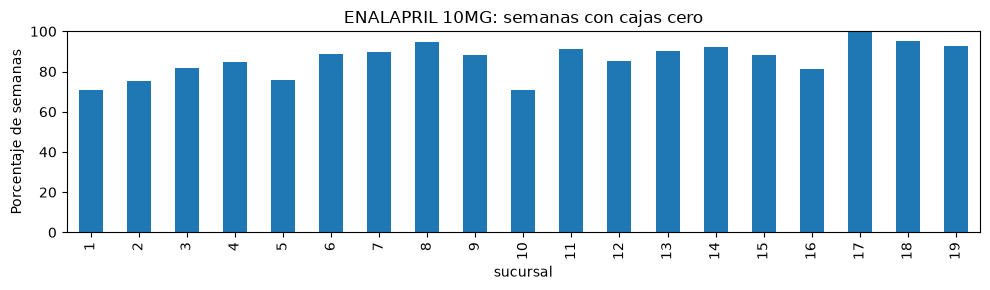

METFORMINA 850MG | sucursales observadas: 19


,sucursal,producto,semanas_totales,semanas_demanda_cero,porcentaje_demanda_cero,demanda_promedio_semanal,inicio,fin
9,1,METFORMINA 850MG,125,100,80.000000,0.272000,2024-01-28,2026-06-14
23,2,METFORMINA 850MG,130,110,84.615385,0.192308,2024-01-07,2026-06-28
37,3,METFORMINA 850MG,128,115,89.843750,0.304688,2024-01-14,2026-06-21
51,4,METFORMINA 850MG,125,113,90.400000,0.112000,2024-03-17,2026-08-02
64,5,METFORMINA 850MG,130,106,81.538462,0.246154,2024-01-21,2026-07-12
78,6,METFORMINA 850MG,134,113,84.328358,0.194030,2024-01-07,2026-07-26
92,7,METFORMINA 850MG,135,129,95.555556,0.044444,2024-01-07,2026-08-02
105,8,METFORMINA 850MG,135,129,95.555556,0.051852,2024-01-07,2026-08-02
119,9,METFORMINA 850MG,132,122,92.424242,0.113636,2024-01-28,2026-08-02
133,10,METFORMINA 850MG,110,100,90.909091,0.109091,2024-01-14,2026-02-15


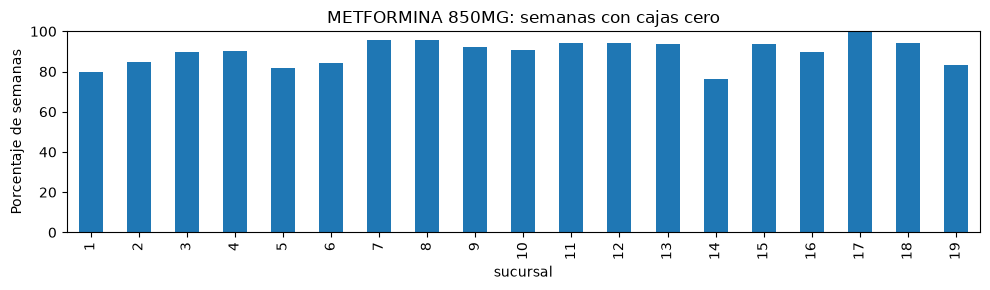

LOSARTAN 50MG | sucursales observadas: 16


,sucursal,producto,semanas_totales,semanas_demanda_cero,porcentaje_demanda_cero,demanda_promedio_semanal,inicio,fin
8,1,LOSARTAN 50MG,97,60,61.855670,0.597938,2024-01-07,2025-11-09
22,2,LOSARTAN 50MG,97,80,82.474227,0.206186,2024-01-07,2025-11-09
36,3,LOSARTAN 50MG,108,88,81.481481,0.222222,2024-01-07,2026-01-25
50,4,LOSARTAN 50MG,96,69,71.875000,0.375000,2024-01-07,2025-11-02
63,5,LOSARTAN 50MG,95,65,68.421053,0.421053,2024-01-07,2025-10-26
77,6,LOSARTAN 50MG,97,86,88.659794,0.134021,2024-01-07,2025-11-09
91,7,LOSARTAN 50MG,97,87,89.690722,0.103093,2024-01-07,2025-11-09
104,8,LOSARTAN 50MG,95,87,91.578947,0.094737,2024-01-07,2025-10-26
118,9,LOSARTAN 50MG,96,80,83.333333,0.166667,2024-01-07,2025-11-02
132,10,LOSARTAN 50MG,97,83,85.567010,0.154639,2024-01-07,2025-11-09


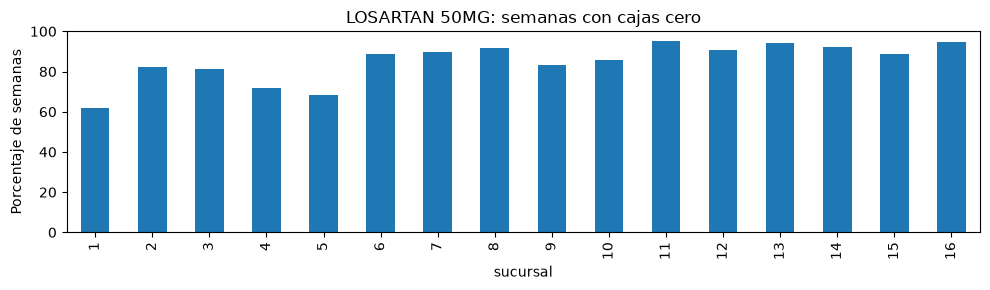

In [2]:
productos_interes = ['ENALAPRIL 10MG', 'METFORMINA 850MG', 'LOSARTAN 50MG']
for producto in productos_interes:
    caso = df_intermitencia[df_intermitencia.producto.str.upper().eq(producto)].sort_values('sucursal')
    print(producto, '| sucursales observadas:', len(caso))
    display(caso)
    if not caso.empty:
        caso.plot.bar(x='sucursal', y='porcentaje_demanda_cero', legend=False, figsize=(10, 3))
        plt.title(f'{producto}: semanas con cajas cero')
        plt.ylabel('Porcentaje de semanas')
        plt.ylim(0, 100)
        plt.tight_layout()
        plt.show()

## Validación de valores atípicos y cantidades negativas

Antes de construir las series semanales se inspeccionaron los registros
con valores negativos en la variable `cantidad`. Estos casos pueden
corresponder a devoluciones, anulaciones o ajustes del ERP, por lo que
se identifican y cuantifican antes del análisis de intermitencia.

En esta etapa los registros no se eliminan automáticamente; su
tratamiento depende de su naturaleza operativa.

In [ ]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('..').resolve()))
from src.preprocessing.demanda_semanal import construir_semanal, resumir_intermitencia

df = pd.read_csv('../datasets/dataset_maestro_dashboard.csv')

# Validación de valores negativos
negativos = df[df['cantidad'] < 0].copy()

print("Cantidad de registros negativos:", len(negativos))

display(
    negativos.sort_values('fecdoc')
)

display(
    negativos.groupby(['sucursal', 'producto'])['cantidad']
    .agg(['count', 'sum', 'min'])
    .sort_values('count', ascending=False)
)

# Luego continúa el flujo normal
semanal = construir_semanal(df)
df_intermitencia = resumir_intermitencia(semanal)


Cantidad de registros negativos: 74


,codpro,prod,tipo,cantidad,unidades,total,fecdoc,sucursal,mes,estacion,producto,categoria_abc
21101,102721,LOSARTAN 50MGX100TAB,PERUFARMA GENERICO,-1.0,0.0,-20.00,2024-01-03 12:00:00,1,1,Verano,LOSARTAN 50MG,Clase B (Rotación Media)
36064,100923,PARACETAMOL 500MG CJAX100TAB,GENFAR,-1.0,0.0,-10.01,2024-01-06 12:00:00,4,1,Verano,PARACETAMOL 500MG,Clase B (Rotación Media)
21237,102721,LOSARTAN 50MGX100TAB,PERUFARMA GENERICO,-1.0,0.0,-20.70,2024-01-27 12:00:00,10,1,Verano,LOSARTAN 50MG,Clase B (Rotación Media)
36699,100923,PARACETAMOL 500MG CJAX100TAB,GENFAR,-1.0,0.0,-10.00,2024-02-13 12:00:00,1,2,Verano,PARACETAMOL 500MG,Clase B (Rotación Media)
21316,102721,LOSARTAN 50MGX100TAB,PERUFARMA GENERICO,-1.0,0.0,-20.70,2024-02-20 12:00:00,1,2,Verano,LOSARTAN 50MG,Clase B (Rotación Media)
...,...,...,...,...,...,...,...,...,...,...,...,...
23878,100018,METFORMINA 850MG TAB CJAX30UND,GENFAR,-1.0,0.0,-10.50,2026-04-25 20:21:08,16,4,Otoño,METFORMINA 850MG,Clase B (Rotación Media)
44291,107417,VITAMINA C+ZINC+D3 NARANJA TAB.EFERV. TBOX20UND,EUROCARE,-1.0,0.0,-14.50,2026-06-07 15:12:53,11,6,Invierno,VITAMINA C+ZINC+D3,Clase A (Alta Rotación)
16454,101410,ENALAPRIL 10MG TAB CJAX140UND,FARM.GENERICOS,-1.0,0.0,-9.00,2026-06-09 19:53:02,10,6,Invierno,ENALAPRIL 10MG,Clase A (Alta Rotación)
44324,107417,VITAMINA C+ZINC+D3 NARANJA TAB.EFERV. TBOX20UND,EUROCARE,-1.0,0.0,-15.12,2026-06-29 11:05:18,1,6,Invierno,VITAMINA C+ZINC+D3,Clase A (Alta Rotación)


,,count,sum,min
sucursal,producto,,,
10,VITAMINA C+ZINC+D3,5,-5.0,-1.0
2,VITAMINA C+ZINC+D3,4,-6.0,-2.0
11,VITAMINA C+ZINC+D3,4,-4.0,-1.0
1,LOSARTAN 50MG,3,-4.0,-2.0
5,VITAMINA C+ZINC+D3,3,-4.0,-2.0
4,VITAMINA C+ZINC+D3,3,-4.0,-2.0
16,VITAMINA C+ZINC+D3,3,-3.0,-1.0
12,VITAMINA C+ZINC+D3,3,-3.0,-1.0
1,VITAMINA C+ZINC+D3,3,-3.0,-1.0


NameError: name 'construir_semanal' is not defined